# Labrador Sea SE-region seasonal timeseries — CESM3 preindustrial development

For each of the following diagnostic fields, plot the seasonal (JFM, AMJ, JAS, OND) area-weighted mean over the SE Labrador Sea box defined in `labsea_utils.REGIONS['LabSea_SE']`, for the analysis window of each run (`CASE_YEARS[run]` — `None` = full record).

Atm (CAM h0a) fields:
* `ICEFRAC` — sea-ice fraction
* `SHFLX`, `LHFLX` — sensible / latent heat flux (up)
* `TS` — surface temperature
* `PRECT` — total precipitation (GPCP obs overlaid, disregarding real calendar years)
* `CLDLOW` — low cloud fraction
* `FSNS`, `FLNS`, `FSDS` — net-solar, net-longwave, downwelling-solar at surface
* `RESSURF` — **derived** net downward surface energy flux = `FSNS − FLNS − SHFLX − LHFLX`

Ocean (MOM6 sfc) fields:
* `MLD` — ocean mixed-layer depth (`mlotst`, σ_T definition, daily → monthly-averaged, then area-weighted over ocean cells in the SE Lab Sea box)

Runs are shown together on the same axis:
* **388** — Lab Sea stays frozen
* **377** — Lab Sea melts

Both individual seasonal values and a smoothed line are drawn.

In [3]:
%load_ext autoreload
%autoreload 2

import importlib
import labsea_utils as lsu
importlib.reload(lsu)

import matplotlib.pyplot as plt
from dask.distributed import Client
from dask_jobqueue import PBSCluster

RUNS    = ["388", "377"]
# Fields to plot — start from the module's VAR_LIST so any new entry there
# (e.g. RESSURF) is picked up automatically.  Override this list explicitly to
# restrict the notebook to a subset for a fast run.
VARS    = list(lsu.VAR_LIST)          # ICEFRAC, SHFLX, LHFLX, TS, PRECT, CLDLOW,
                                      # FSNS, FLNS, FSDS, RESSURF
SEASONS = ["JFM", "AMJ", "JAS", "OND"]
REGION  = "LabSea_SE"
FIG_DIR = "./figs"
ROLL    = 5    # years, centered rolling mean for the highlighted line

# ── Per-case year ranges ───────────────────────────────────────────────────
# Set an explicit (y0, y1) for each run to restrict the analysis window.
# Set an entry to None to use the run's full available record — the default
# for a full-length timeseries.
CASE_YEARS = {
    "388": (5,20),   # None → full record
    "377": (5,20),
}

# MOM/MLD — daily files are heavy, so keep this window tighter than the atm
# side by default.  Set to None to use the full MOM record.
MOM_VARS       = list(lsu.MOM_VAR_LIST)   # ['MLD']
CASE_YEARS_MOM = {
    "388": (5,20),
    "377": (5,20),
}

print("Variables:", VARS)
print("MOM vars :", MOM_VARS)
for r in RUNS:
    y0, y1 = lsu.year_range(r)
    print(f"Run {r}: atm full record years {y0:04d}-{y1:04d}"
          f"  → using CASE_YEARS={CASE_YEARS.get(r)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Variables: ['ICEFRAC', 'SHFLX', 'LHFLX', 'TS', 'PRECT', 'CLDLOW', 'FSNS', 'FLNS', 'FSDS', 'RESSURF']
MOM vars : ['MLD']
Run 388: atm full record years 0001-0060  → using CASE_YEARS=(5, 20)
Run 377: atm full record years 0001-0160  → using CASE_YEARS=(5, 20)


In [4]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",   
    cores=4,
    memory="32GB",
    processes=4,      # one process per core (safe default)cesm2
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=32)
client = Client(cluster)

client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/8787/status,
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.176:33739,Workers: 0
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
# Open atm datasets — each run uses its own CASE_YEARS window (None → full record).
datasets = {}
for r in RUNS:
    yrs = CASE_YEARS.get(r)
    print(f"Opening atm run {r}  year_range={yrs} ...")
    datasets[r] = lsu.load_run(r, VARS, year_range=yrs)
    print(f"  {r}: {datasets[r].sizes['time']} monthly records")

Opening atm run 388  year_range=(5, 20) ...
  388: 192 monthly records
Opening atm run 377  year_range=(5, 20) ...
  377: 192 monthly records


In [6]:
# Compute area-weighted monthly regional-mean timeseries once per (var, run).
monthly_ts = {var: {} for var in VARS}
for var in VARS:
    for r in RUNS:
        ts = lsu.regional_mean_ts(datasets[r], var, REGION)
        ts.load()
        monthly_ts[var][r] = ts
    print(f"  built monthly regional-mean timeseries for {var}")

# GPCP monthly regional-mean for PRECT — full obs record, aligned by index
# onto the model year axis when plotted.
gpcp = lsu.load_gpcp()
monthly_ts["PRECT"]["GPCP"] = lsu.obs_regional_mean_ts(gpcp, "PRECT", REGION).load()
print(f"  added GPCP monthly ts (n={monthly_ts['PRECT']['GPCP'].sizes['time']})")

  built monthly regional-mean timeseries for ICEFRAC
  built monthly regional-mean timeseries for SHFLX
  built monthly regional-mean timeseries for LHFLX
  built monthly regional-mean timeseries for TS
  built monthly regional-mean timeseries for PRECT
  built monthly regional-mean timeseries for CLDLOW
  built monthly regional-mean timeseries for FSNS
  built monthly regional-mean timeseries for FLNS
  built monthly regional-mean timeseries for FSDS
  built monthly regional-mean timeseries for RESSURF
  added GPCP monthly ts (n=451)


  saved ./figs/ts_ICEFRAC_JFM_LabSea_SE.png


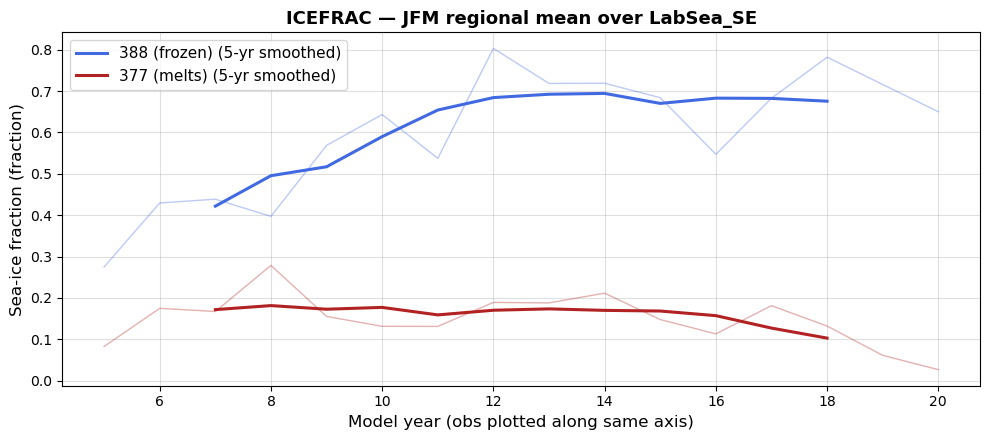

  saved ./figs/ts_ICEFRAC_AMJ_LabSea_SE.png


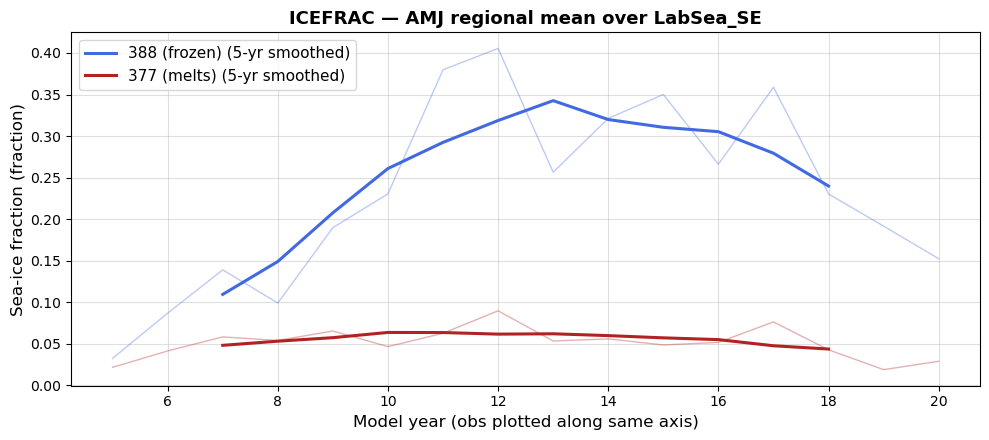

  saved ./figs/ts_ICEFRAC_JAS_LabSea_SE.png


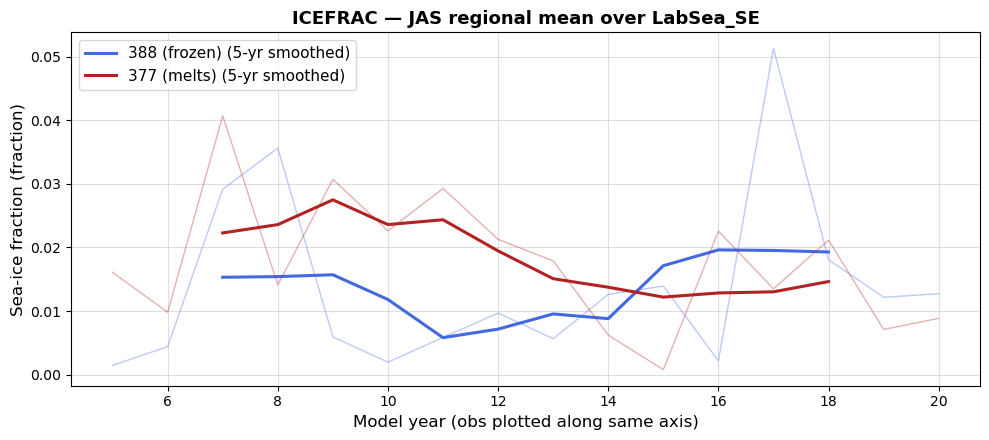

  saved ./figs/ts_ICEFRAC_OND_LabSea_SE.png


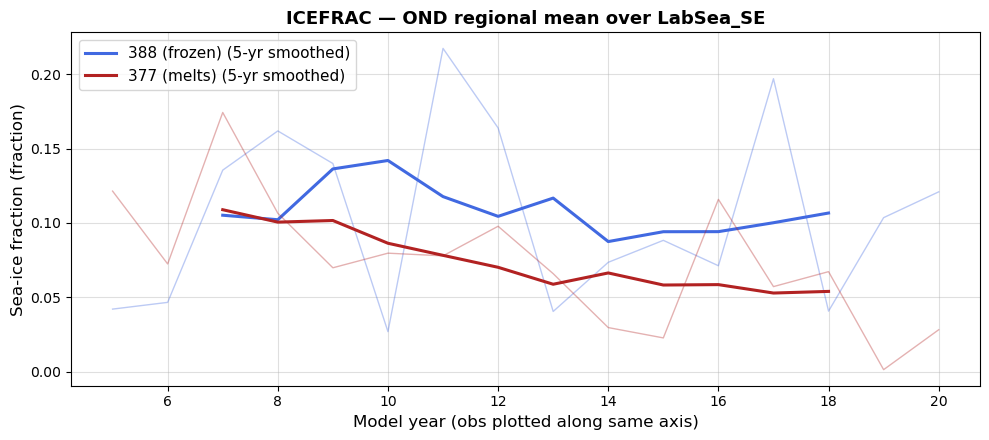

  saved ./figs/ts_SHFLX_JFM_LabSea_SE.png


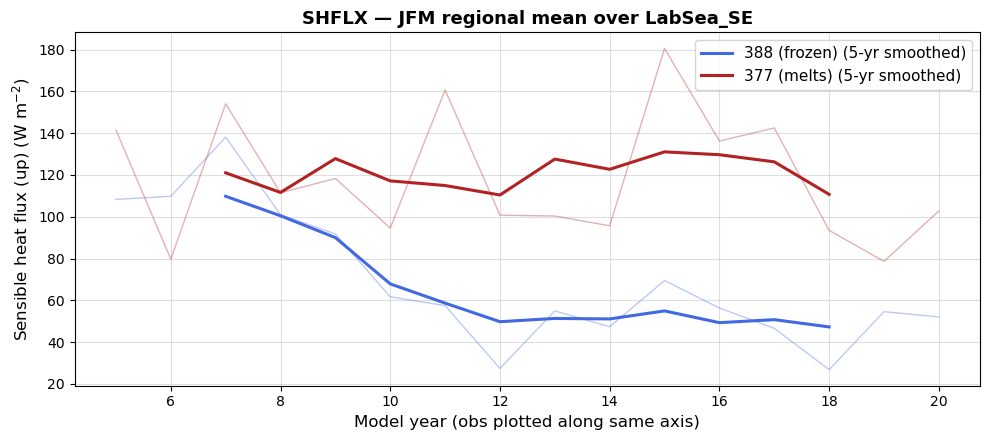

  saved ./figs/ts_SHFLX_AMJ_LabSea_SE.png


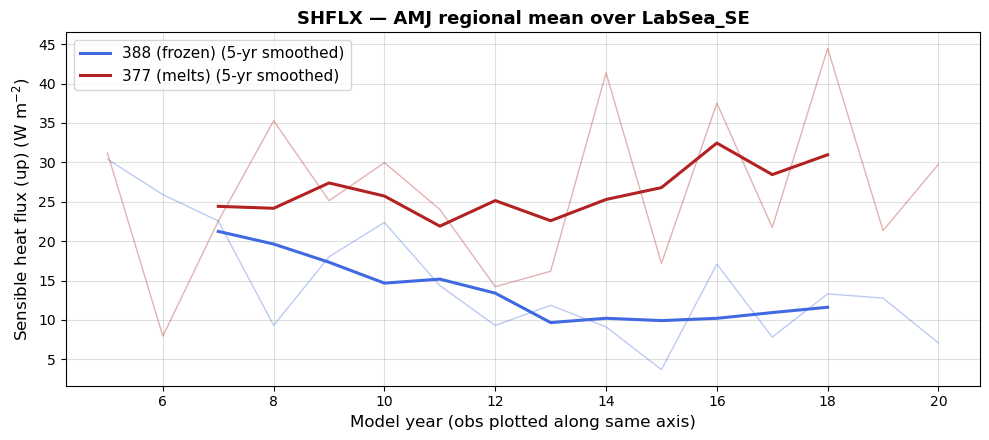

  saved ./figs/ts_SHFLX_JAS_LabSea_SE.png


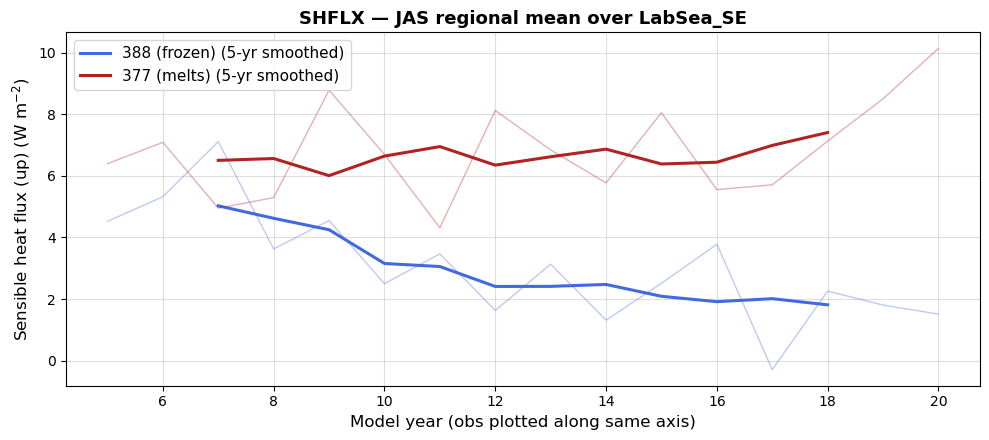

  saved ./figs/ts_SHFLX_OND_LabSea_SE.png


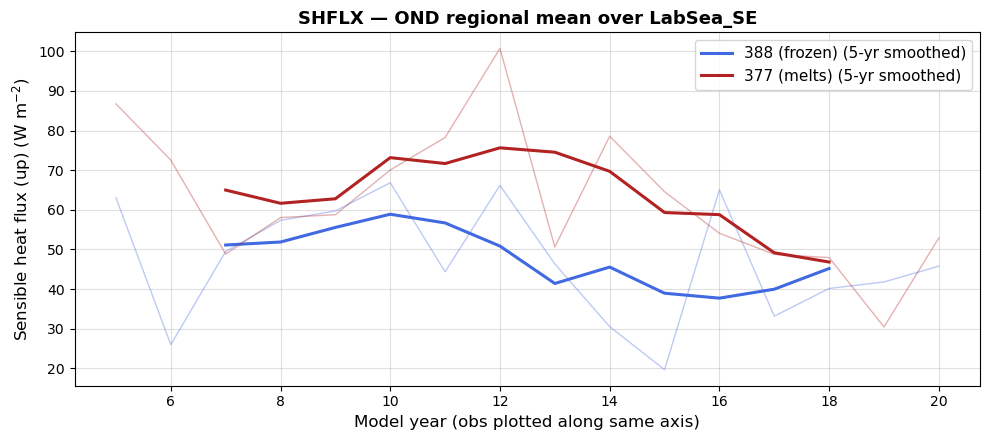

  saved ./figs/ts_LHFLX_JFM_LabSea_SE.png


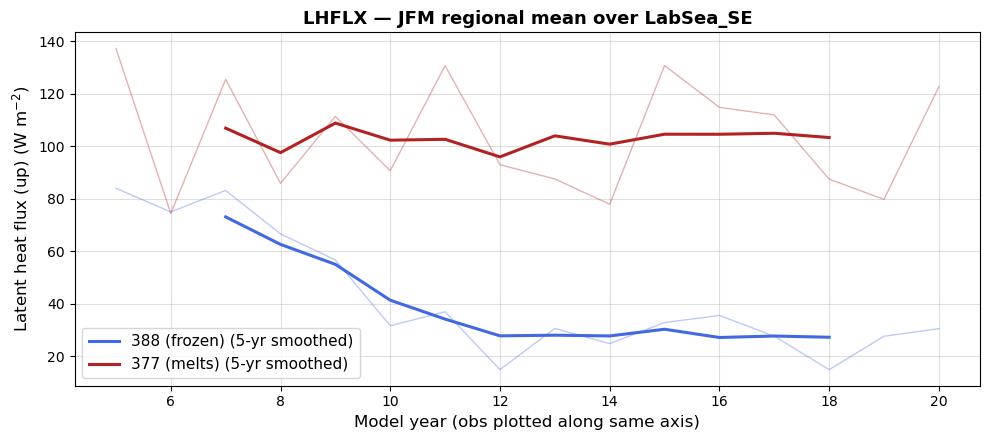

  saved ./figs/ts_LHFLX_AMJ_LabSea_SE.png


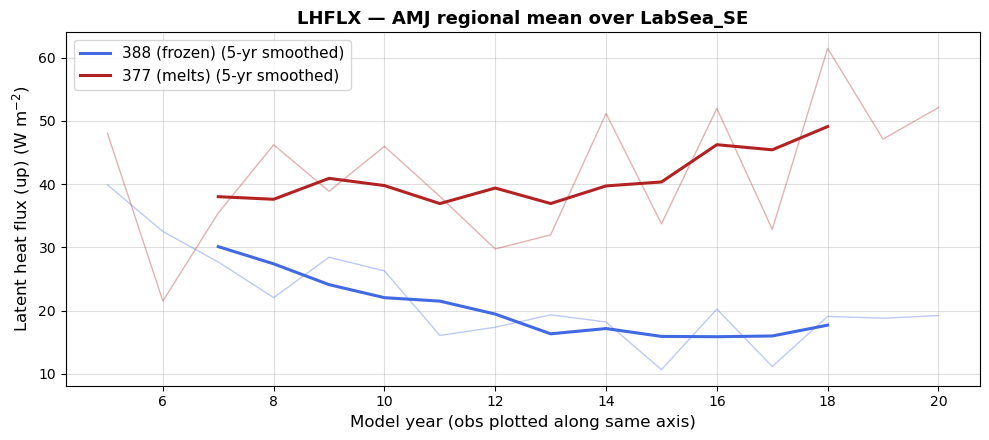

  saved ./figs/ts_LHFLX_JAS_LabSea_SE.png


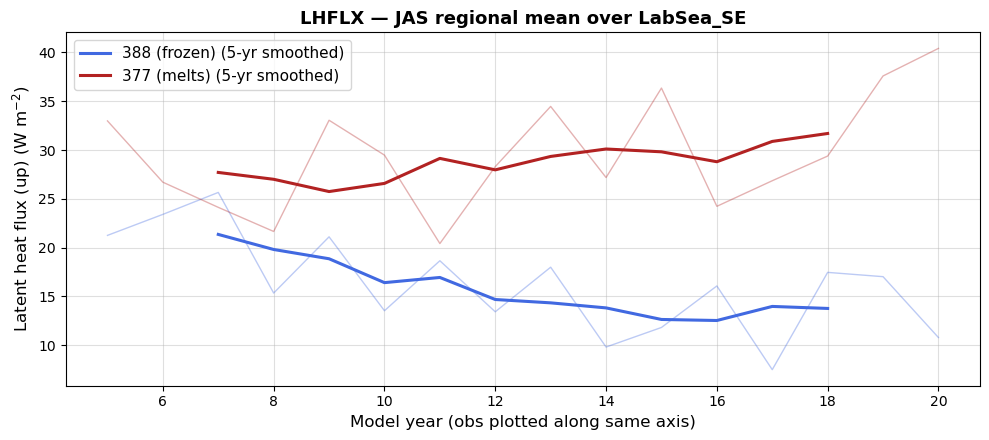

  saved ./figs/ts_LHFLX_OND_LabSea_SE.png


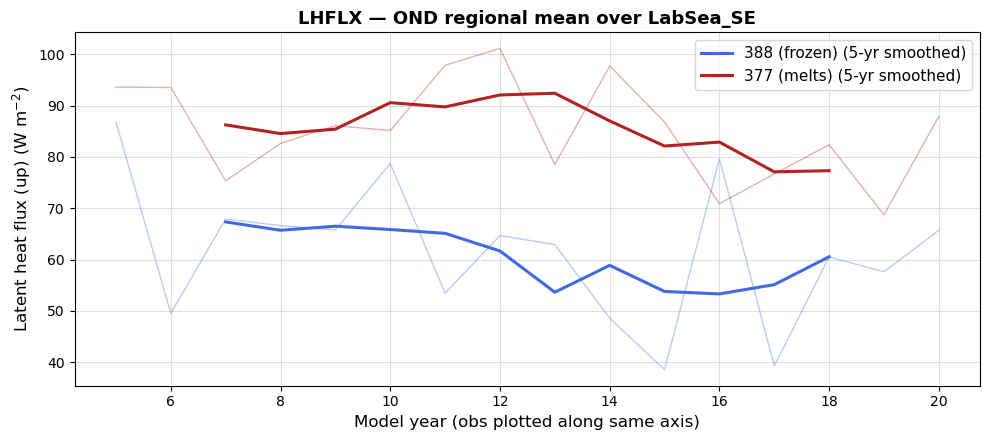

  saved ./figs/ts_TS_JFM_LabSea_SE.png


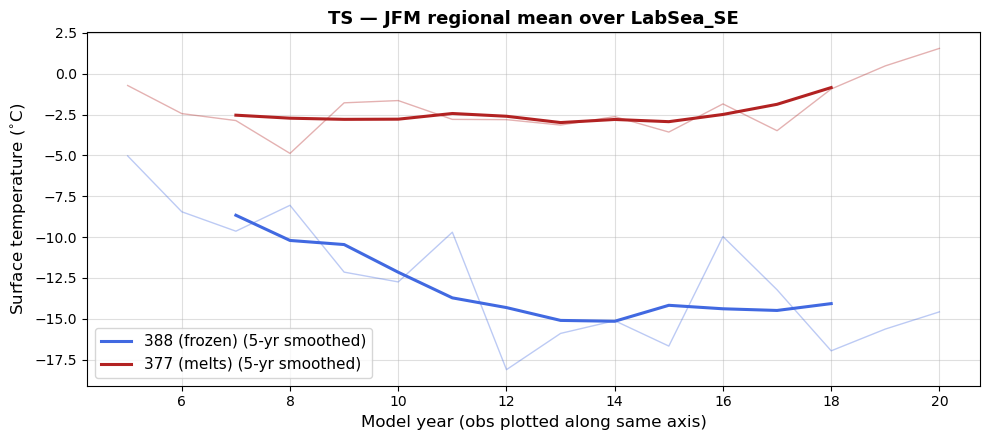

  saved ./figs/ts_TS_AMJ_LabSea_SE.png


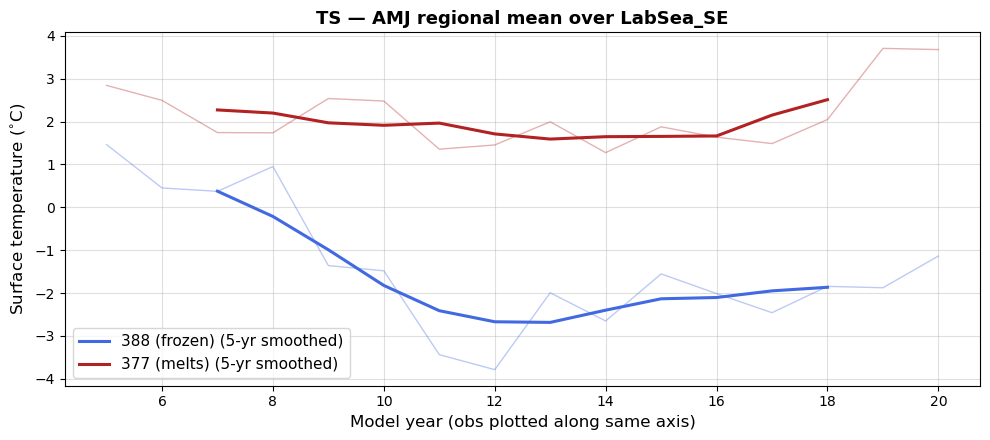

  saved ./figs/ts_TS_JAS_LabSea_SE.png


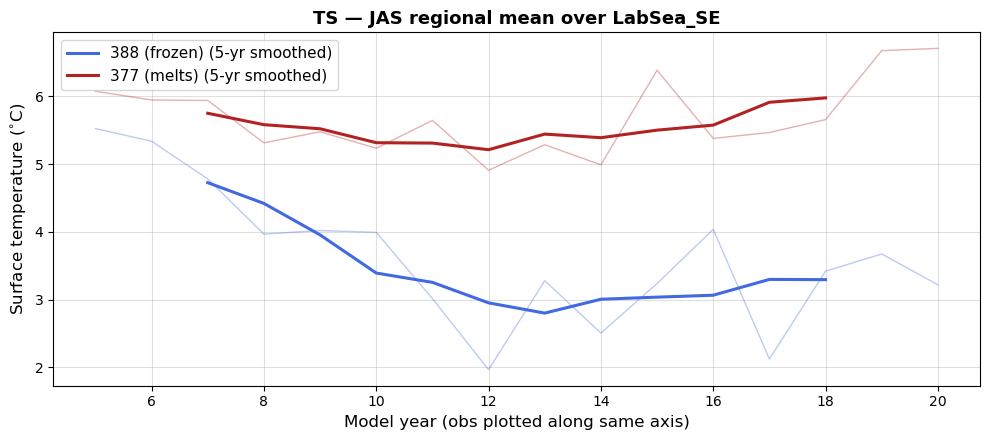

  saved ./figs/ts_TS_OND_LabSea_SE.png


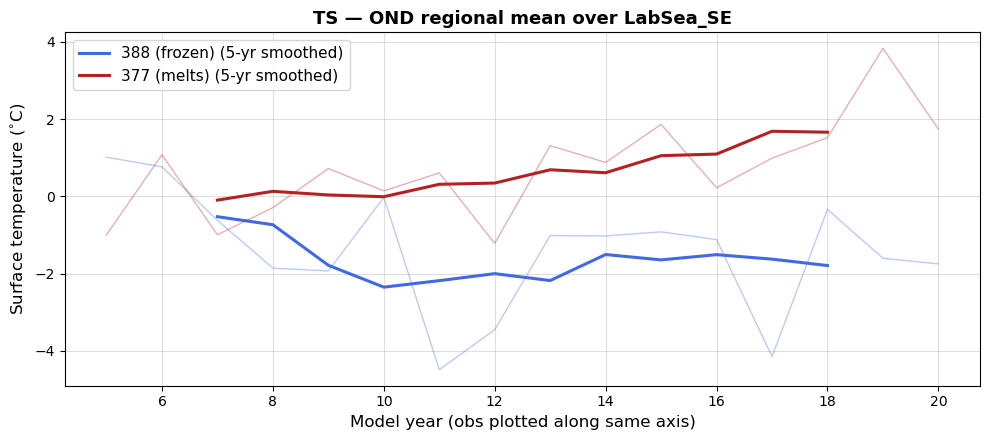

  saved ./figs/ts_PRECT_JFM_LabSea_SE.png


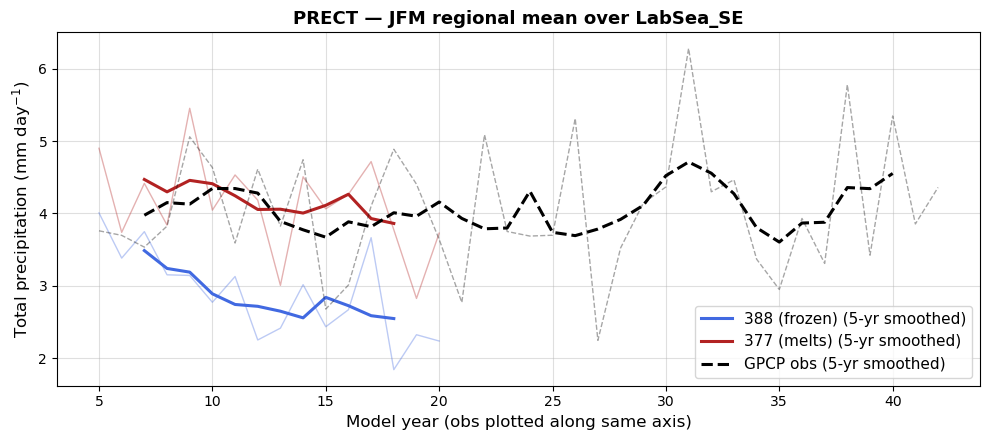

  saved ./figs/ts_PRECT_AMJ_LabSea_SE.png


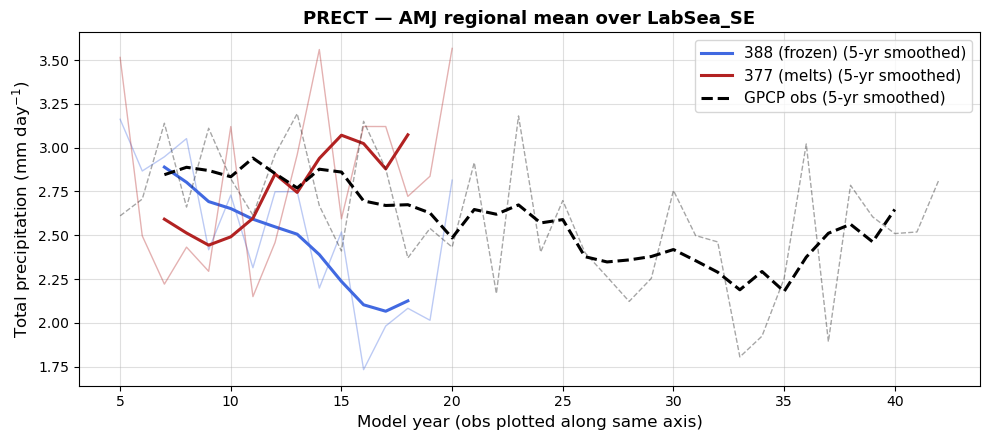

  saved ./figs/ts_PRECT_JAS_LabSea_SE.png


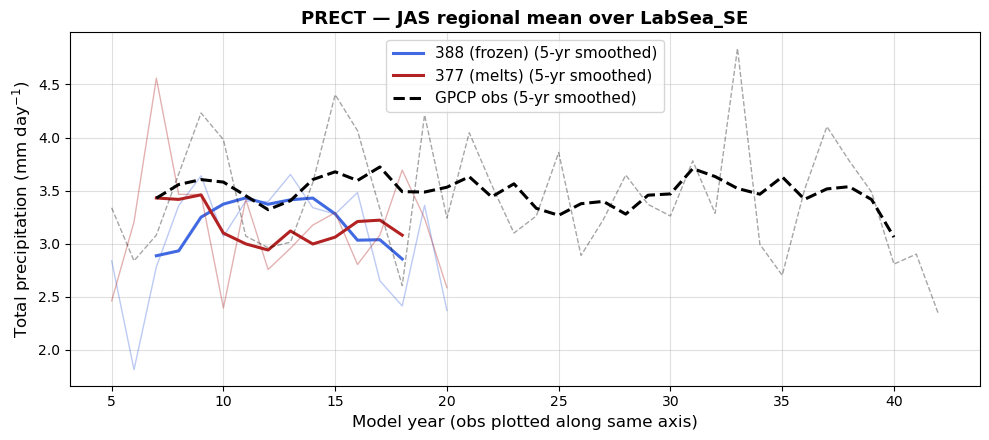

  saved ./figs/ts_PRECT_OND_LabSea_SE.png


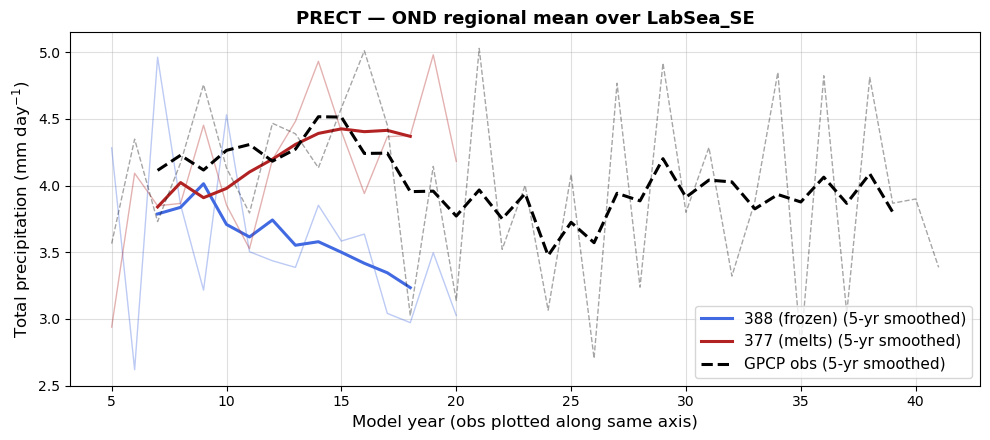

  saved ./figs/ts_CLDLOW_JFM_LabSea_SE.png


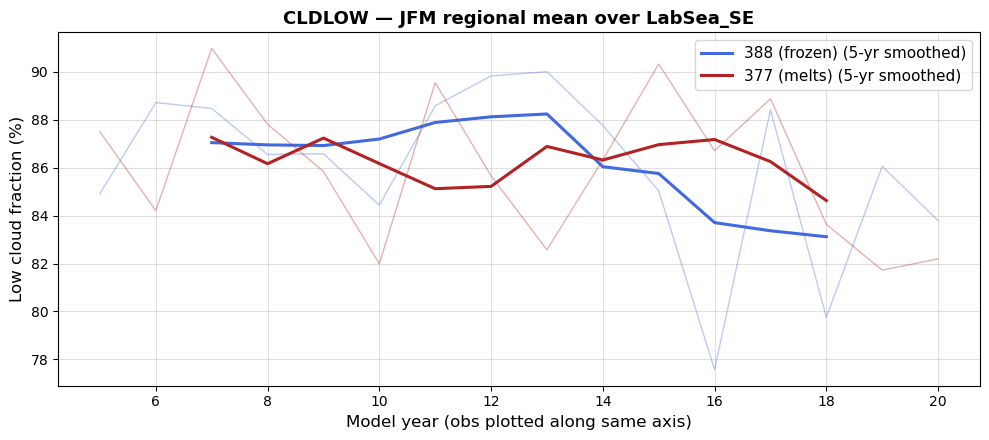

  saved ./figs/ts_CLDLOW_AMJ_LabSea_SE.png


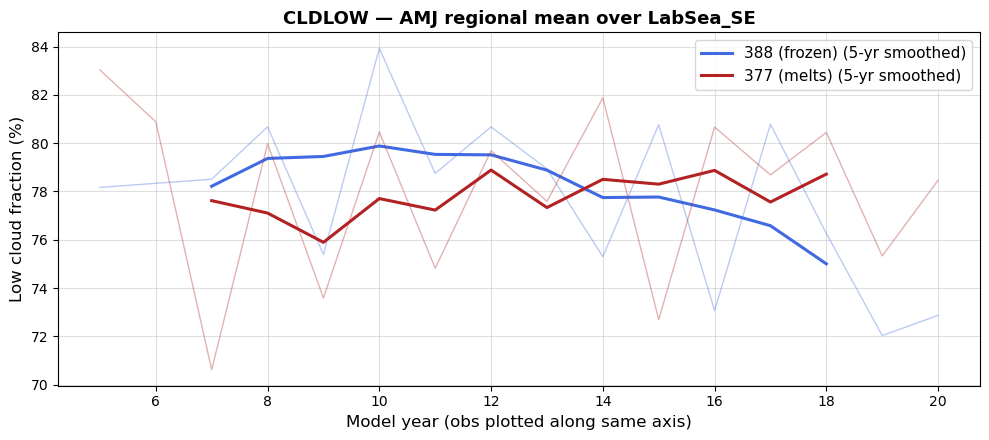

  saved ./figs/ts_CLDLOW_JAS_LabSea_SE.png


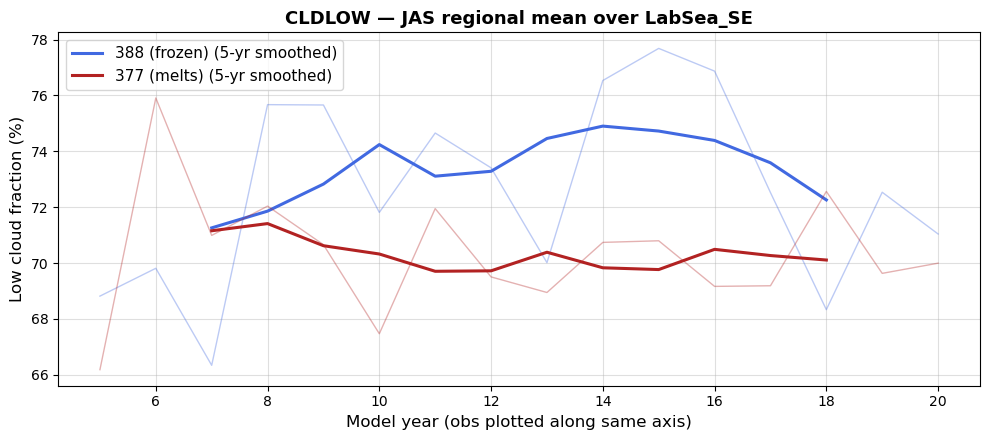

  saved ./figs/ts_CLDLOW_OND_LabSea_SE.png


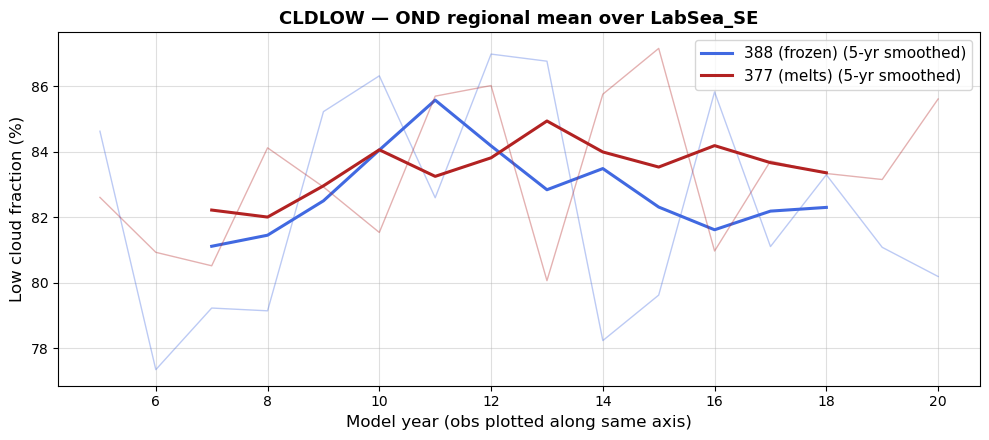

  saved ./figs/ts_FSNS_JFM_LabSea_SE.png


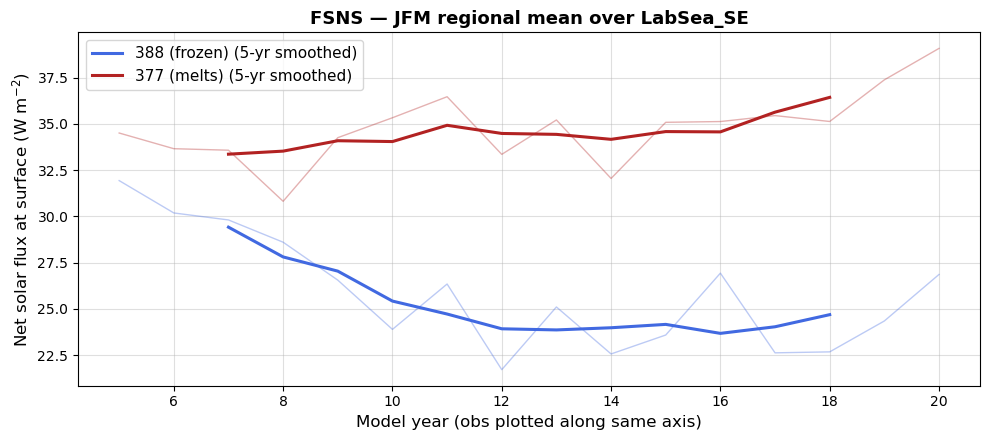

  saved ./figs/ts_FSNS_AMJ_LabSea_SE.png


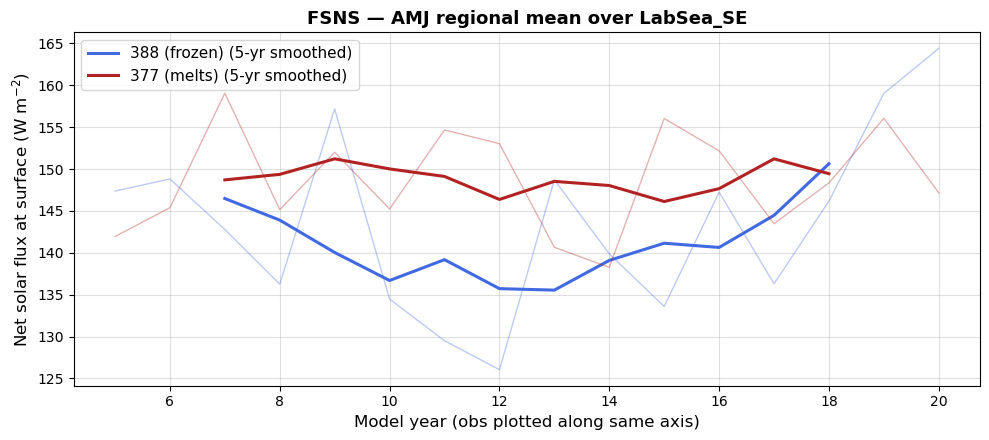

  saved ./figs/ts_FSNS_JAS_LabSea_SE.png


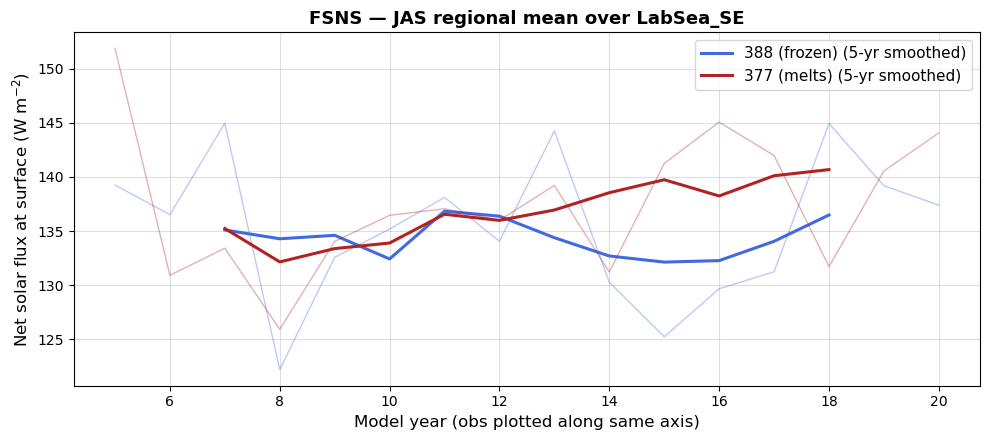

  saved ./figs/ts_FSNS_OND_LabSea_SE.png


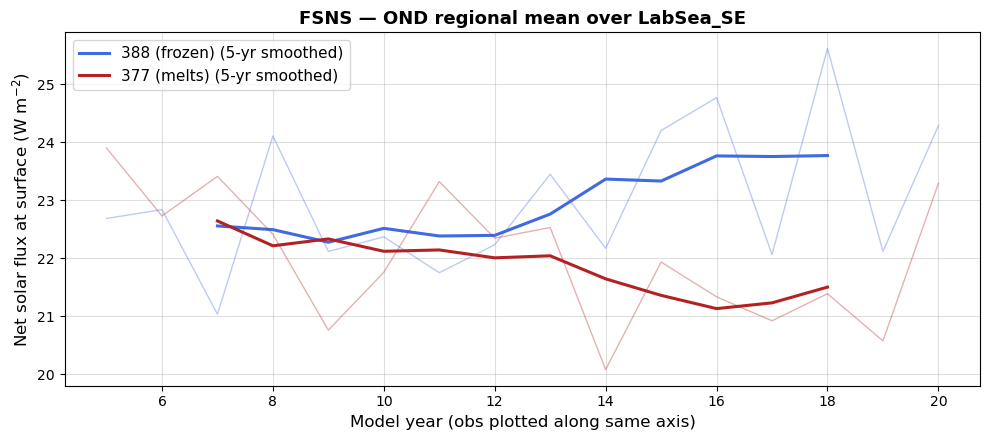

  saved ./figs/ts_FLNS_JFM_LabSea_SE.png


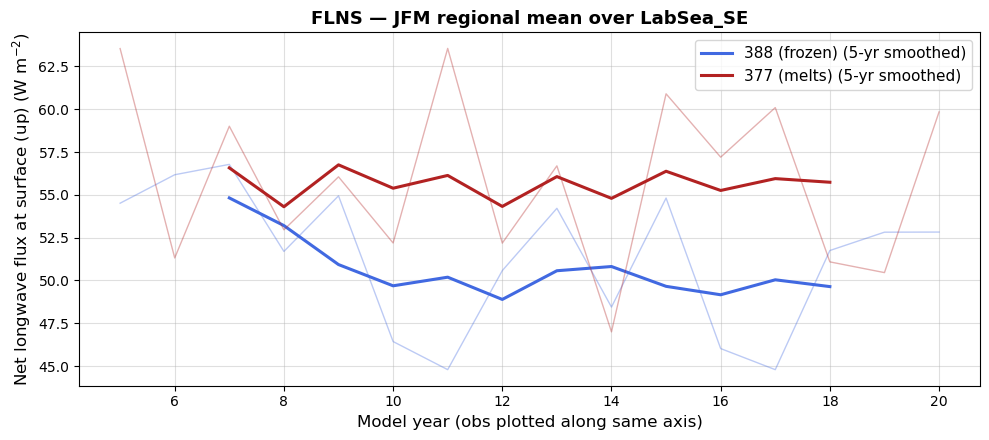

  saved ./figs/ts_FLNS_AMJ_LabSea_SE.png


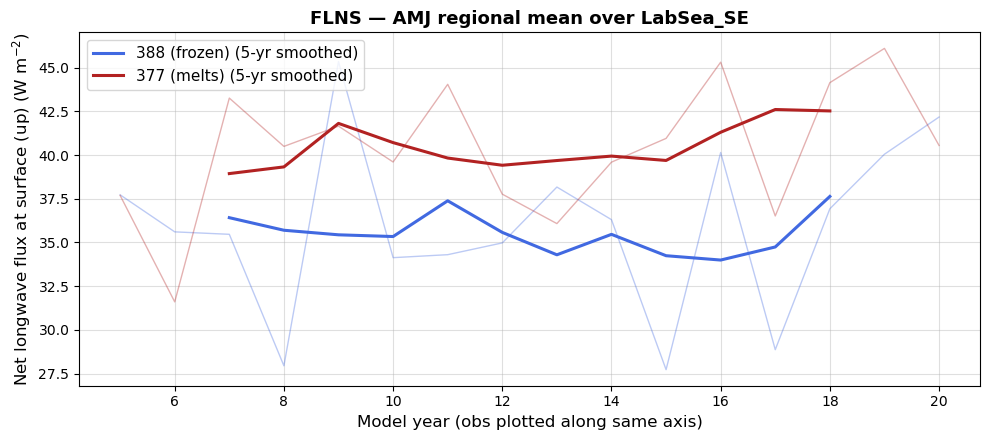

  saved ./figs/ts_FLNS_JAS_LabSea_SE.png


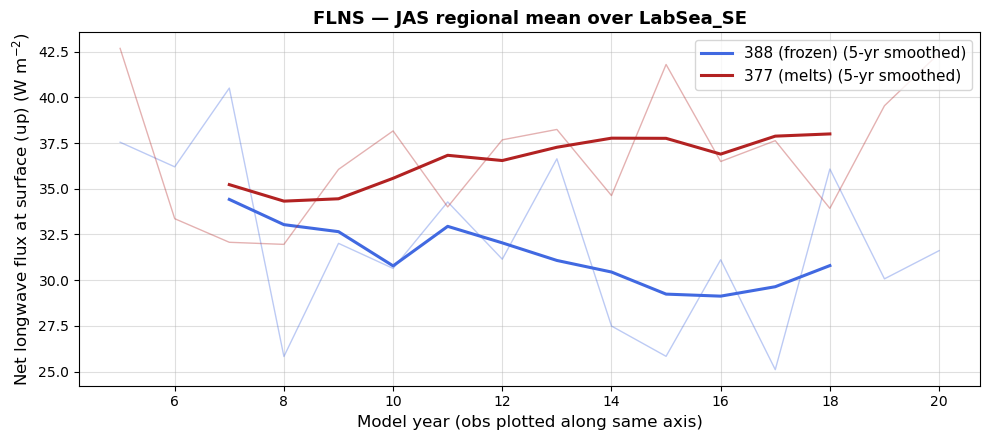

  saved ./figs/ts_FLNS_OND_LabSea_SE.png


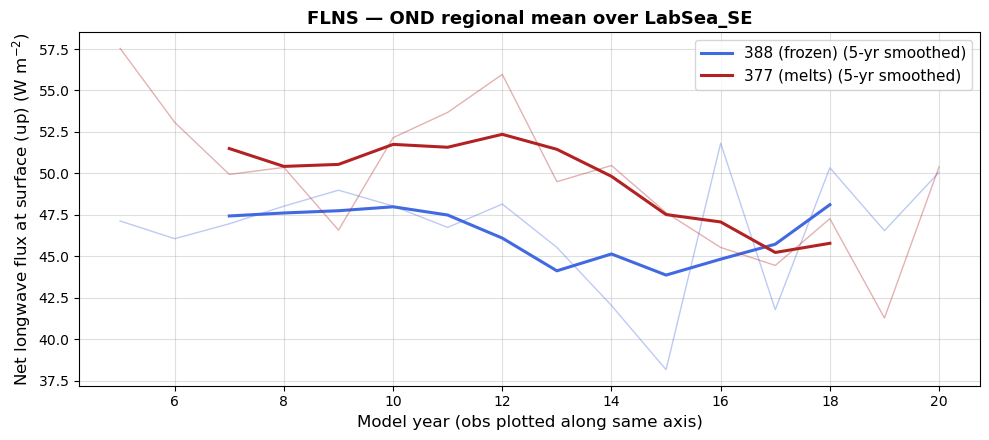

  saved ./figs/ts_FSDS_JFM_LabSea_SE.png


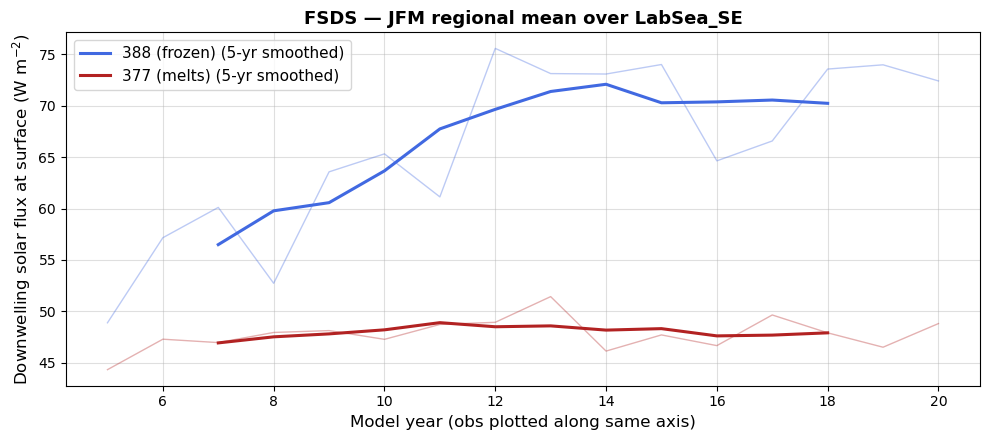

  saved ./figs/ts_FSDS_AMJ_LabSea_SE.png


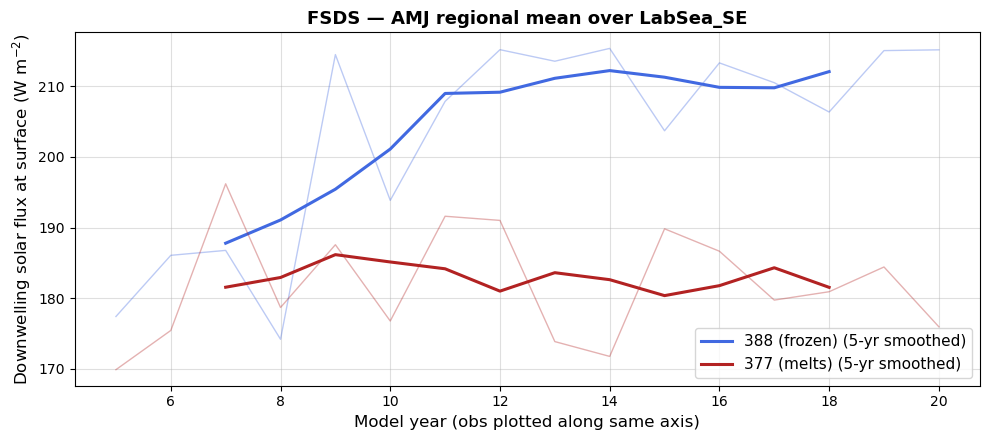

  saved ./figs/ts_FSDS_JAS_LabSea_SE.png


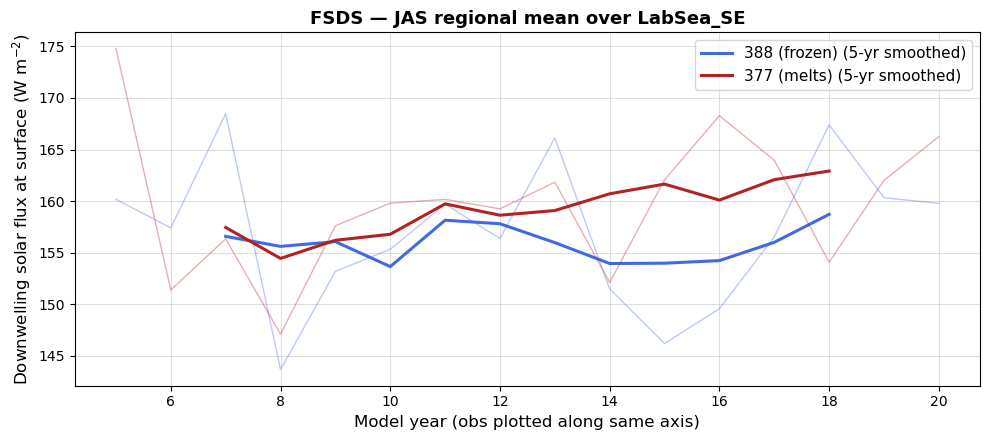

  saved ./figs/ts_FSDS_OND_LabSea_SE.png


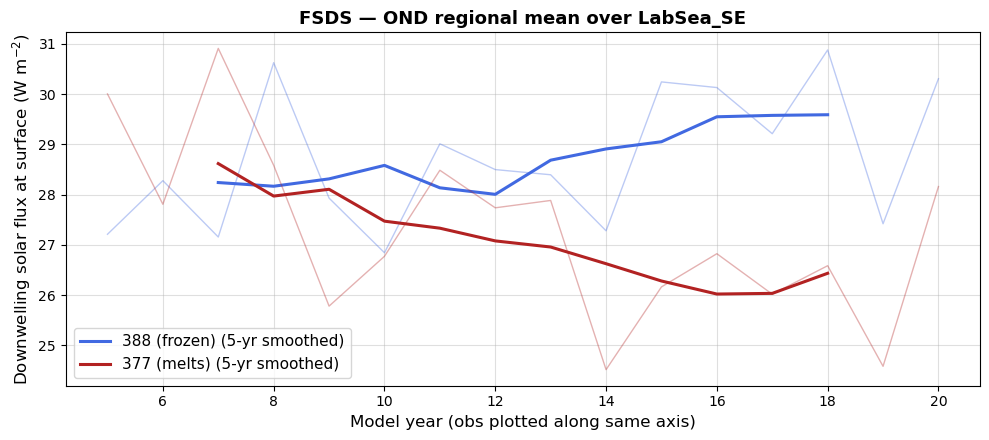

  saved ./figs/ts_RESSURF_JFM_LabSea_SE.png


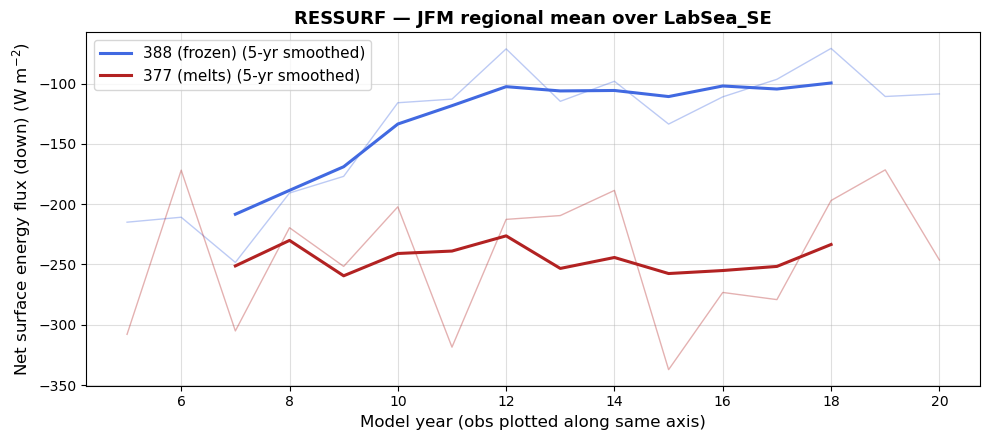

  saved ./figs/ts_RESSURF_AMJ_LabSea_SE.png


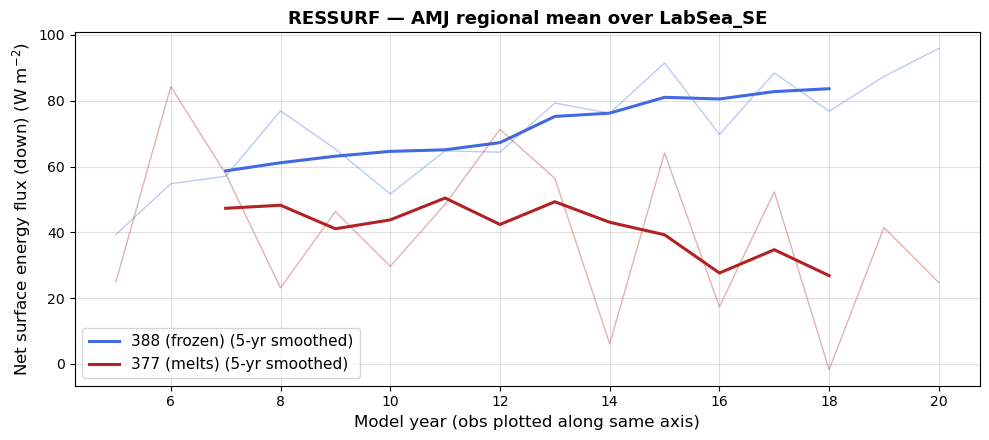

  saved ./figs/ts_RESSURF_JAS_LabSea_SE.png


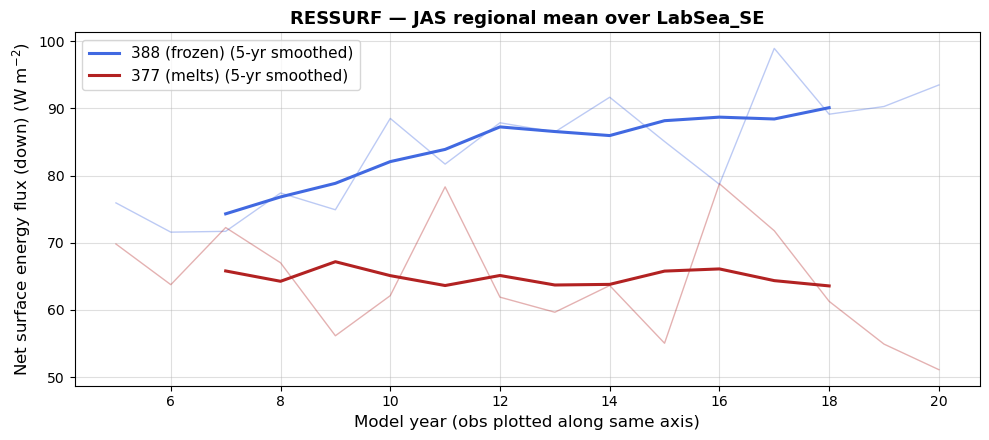

  saved ./figs/ts_RESSURF_OND_LabSea_SE.png


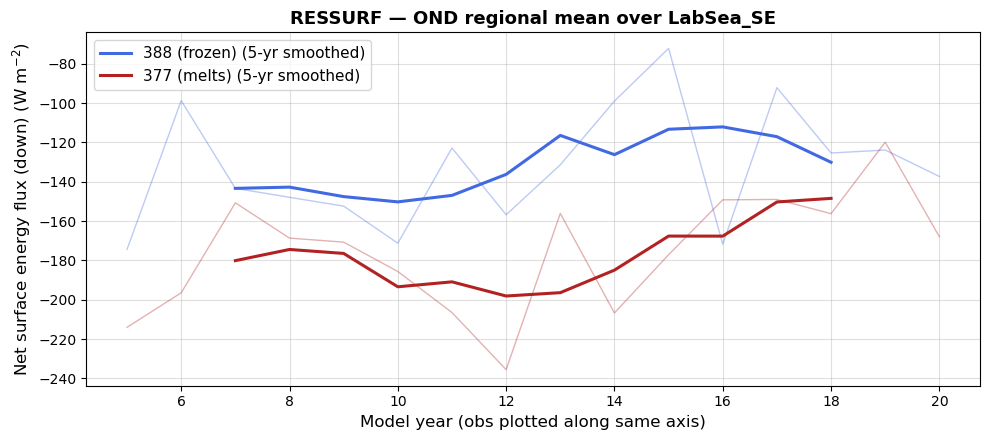

In [7]:
# One figure per (var, season): seasonal-mean line + smoothed line for each run.
# Any obs entry (e.g. GPCP for PRECT) is drawn along the model x-axis starting
# at the first model year — the actual obs years are disregarded.
for var in VARS:
    for season in SEASONS:
        ts_by_run = {}
        for case_id in list(monthly_ts[var].keys()):   # RUNS + any obs (GPCP)
            ts_by_run[case_id] = lsu.to_seasonal_ts(monthly_ts[var][case_id], season)
        lsu.plot_seasonal_ts(ts_by_run, var, season, REGION,
                             save_dir=FIG_DIR, roll=ROLL)
        plt.show()

## Ocean (MOM) — mixed-layer depth timeseries
Open the MOM `sfc` daily stream, aggregate to monthly means, then area-weight
over the ocean cells inside the SE Labrador Sea box and plot the same seasonal
timeseries as for the atm fields.

Opening MOM run 388  year_range=(5, 20) ...


/glade/work/rneale/git/python-scripts/CAM7_CESM3_dev/LabSea/labsea_utils.py:376: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_mfdataset(
/glade/work/rneale/git/python-scripts/CAM7_CESM3_dev/LabSea/labsea_utils.py:376: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attri

  388: 192 monthly records
    built regional-mean timeseries for MLD
Opening MOM run 377  year_range=(5, 20) ...


/glade/work/rneale/git/python-scripts/CAM7_CESM3_dev/LabSea/labsea_utils.py:376: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_mfdataset(
/glade/work/rneale/git/python-scripts/CAM7_CESM3_dev/LabSea/labsea_utils.py:376: FutureWarning: In a future version, xarray will not decode the variable 'average_DT' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attri

  377: 192 monthly records
    built regional-mean timeseries for MLD
  saved ./figs/ts_MLD_JFM_LabSea_SE.png


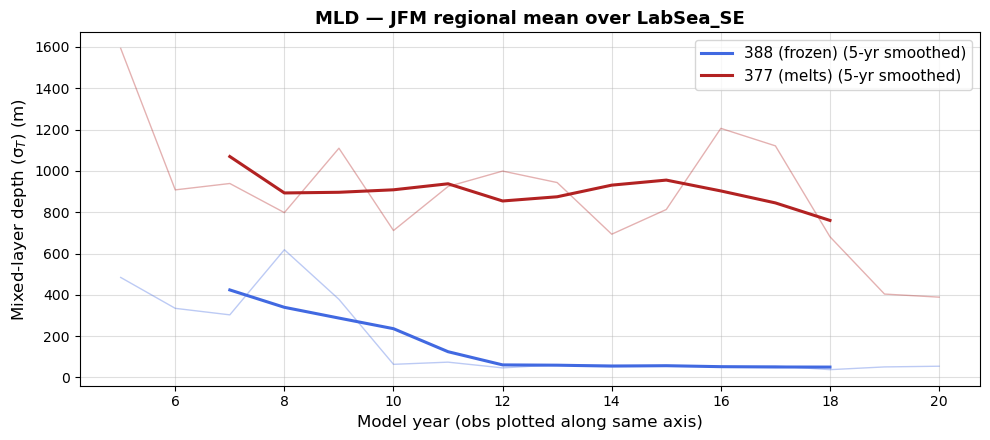

  saved ./figs/ts_MLD_AMJ_LabSea_SE.png


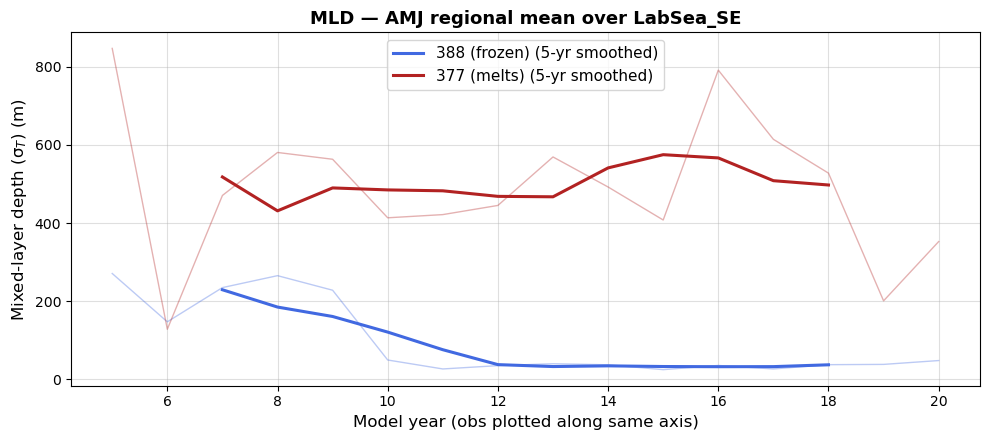

  saved ./figs/ts_MLD_JAS_LabSea_SE.png


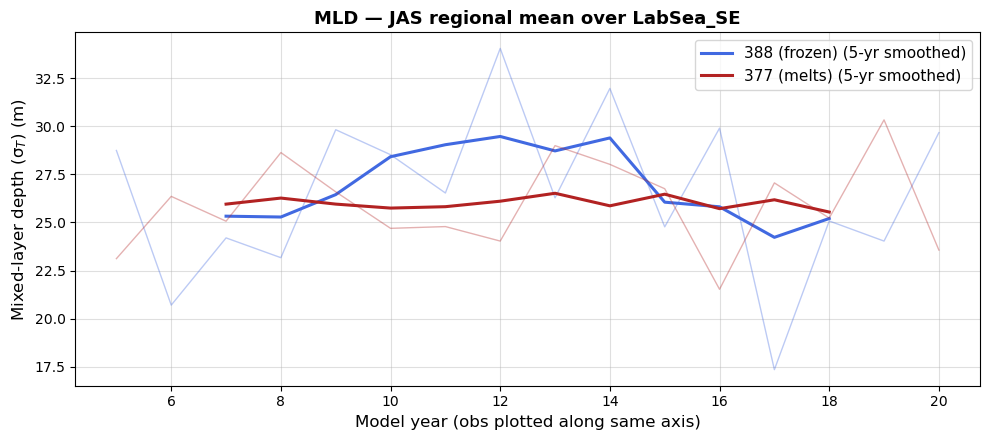

  saved ./figs/ts_MLD_OND_LabSea_SE.png


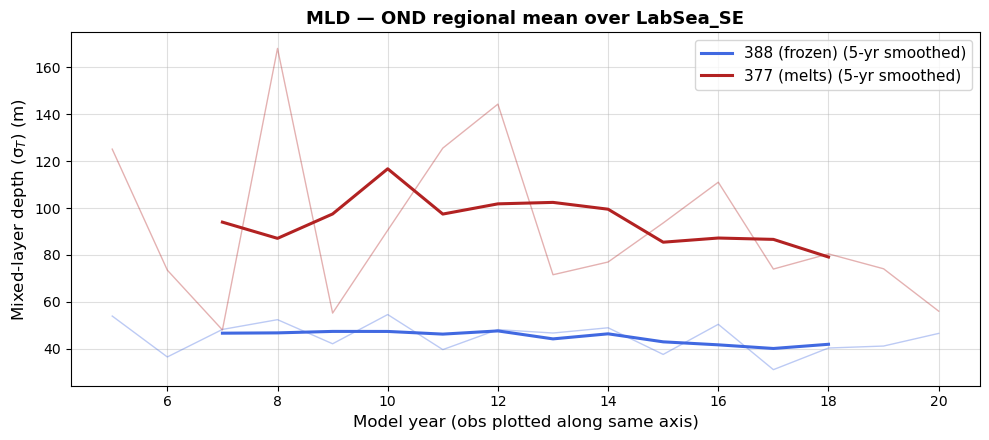

In [8]:
# Open MOM data (daily sfc → monthly means) and build regional-mean timeseries.
mom_datasets = {}
mom_monthly_ts = {var: {} for var in MOM_VARS}
for r in RUNS:
    yrs = CASE_YEARS_MOM.get(r)
    print(f"Opening MOM run {r}  year_range={yrs} ...")
    mom_datasets[r] = lsu.load_run_mom(r, mom_vars=MOM_VARS, year_range=yrs)
    print(f"  {r}: {mom_datasets[r].sizes['time']} monthly records")
    for var in MOM_VARS:
        ts = lsu.mom_regional_mean_ts(mom_datasets[r], var, REGION)
        ts.load()
        mom_monthly_ts[var][r] = ts
        print(f"    built regional-mean timeseries for {var}")

# One figure per (var, season): seasonal-mean + smoothed line for each run.
for var in MOM_VARS:
    for season in SEASONS:
        ts_by_run = {}
        for case_id in list(mom_monthly_ts[var].keys()):
            ts_by_run[case_id] = lsu.to_seasonal_ts(mom_monthly_ts[var][case_id], season)
        lsu.plot_seasonal_ts(ts_by_run, var, season, REGION,
                             save_dir=FIG_DIR, roll=ROLL)
        plt.show()